# The Graph of Averages

The regression line is a smoothed version of the graph of averages. If the graph of averages follows a straight line, that line is the regression line.

Loading required package: haven



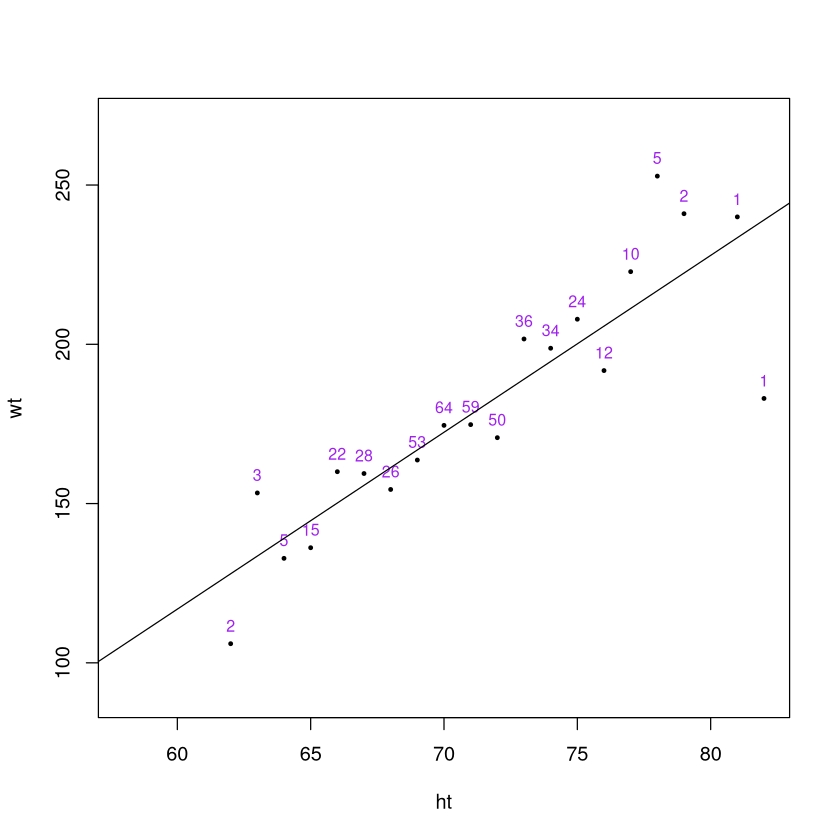

In [1]:
# Data
require(haven)
demo <- read_xpt('../../09 Data Sets/DEMO_C.XPT')
males <- demo[demo$RIAGENDR == 1 & demo$RIDAGEEX >= 216 & demo$RIDAGEEX <= 288,]$SEQN
bm <- read_xpt('../../09 Data Sets/BMX_C.XPT')
x <- na.omit(bm[bm$SEQN %in% males,c('BMXHT','BMXWT')])
old.digits = getOption("digits")
options(digits=1)
df <- data.frame(height=round(x$BMXHT*.4), weight=round(x$BMXWT*2.2))

# The Graph of averages calculation (mean and count)
agg <- aggregate(weight ~ height, data=df, FUN=function(x){c(mean=mean(x), count=length(x))})
ht <- agg$height
m.ht <- mean(ht)
sd.ht <- sd(ht)
wt <- agg$weight[,1]
m.wt <- mean(wt)
sd.wt <- sd(wt)
cor.avg <- cor(ht, wt)
cnt <- agg$weight[,2]
plot(x=ht,y=wt, pch=20, cex=.6, xlim=c(58, 82), ylim=c(90, 270))
text(x=ht,y=wt, labels=cnt, pos=3, cex=.8, col="purple")
regression.points <- data.frame(
    x=c(m.ht-2*sd.ht, m.ht+sd.ht, m.ht+2*sd.ht),
    y=c(m.wt-2*cor.avg*sd.wt, m.wt+cor.avg*sd.wt, m.wt+2*cor.avg*sd.wt))
regression.slope <- (regression.points$y[2] - regression.points$y[1]) / (regression.points$x[2] - regression.points$x[1])
regression.intercept <- regression.points$y[1] - regression.slope * regression.points$x[1]
abline(a=regression.intercept, b=regression.slope)
options(digits=old.digits)

In [2]:
rm(list=ls())

Sometimes the regression line smooths away too much. If there is a non-linear association between the two variables, then the regression line will pass it by. It would be better to use the graph of averages.